GeoPandas: Geospatial Analysis

In [167]:
# importing relevant libraries
import io
import textwrap

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import osmnx as ox
import pandas as pd
import requests

In [168]:
# load ward boundaries from the ArcGIS FeatureServer as GeoJSON (Exeter only), with local fallback
url = (
    "https://services1.arcgis.com/ESMARspQHYMw9BZ9/ArcGIS/rest/services/"
    "WD_MAY_2025_UK_BFC_V2/FeatureServer/0/query?"
    "where=LAD25NM%3D%27Exeter%27&outFields=*&outSR=4326&f=geojson"
)
try:
    districts = gpd.read_file(url)
    print("Loaded Exeter wards from ArcGIS FeatureServer.")
except Exception as e:
    print(f"Could not load from service: {e}. Falling back to local GeoPackage.")
    try:
        districts = gpd.read_file("WD_MAY_2025_UK_BFC_V2_-5185687143062460842.gpkg")
        print("Loaded local GeoPackage.")
    except FileNotFoundError as e:
        raise RuntimeError(f"Could not load ward boundaries: {e}")

Loaded Exeter wards from ArcGIS FeatureServer.


In [169]:
# inspect available columns and first few rows to understand the district data
print("Available columns:")
print(districts.columns.tolist())
print("\nFirst 5 rows (non-geometry columns):")
print(districts.drop(columns=['geometry']).head())
print(f"\nTotal districts: {len(districts)}")
print("\nDistrict names from data:")
if 'WD20NM' in districts.columns:
    print(districts['WD20NM'].tolist())

Available columns:
['FID', 'WD25CD', 'WD25NM', 'WD25NMW', 'LAD25CD', 'LAD25NM', 'LAD25NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'Shape__Area', 'Shape__Length', 'GlobalID', 'geometry']

First 5 rows (non-geometry columns):
    FID     WD25CD                   WD25NM WD25NMW    LAD25CD LAD25NM  \
0  2073  E05011011               Alphington          E07000041  Exeter   
1  2074  E05011012     Duryard and St James          E07000041  Exeter   
2  2075  E05011013                   Exwick          E07000041  Exeter   
3  2076  E05011014                Heavitree          E07000041  Exeter   
4  2077  E05011015  Mincinglake and Whipton          E07000041  Exeter   

  LAD25NMW   BNG_E  BNG_N      LONG        LAT   Shape__Area  Shape__Length  \
0           292041  90375 -3.530173  50.702950  5.663131e+06   14165.415026   
1           291818  94691 -3.534597  50.741708  4.546631e+06   11495.765556   
2           290400  93605 -3.554362  50.731679  4.167384e+06   12231.201285   
3           294076  

In [179]:
# detailed column information
print("=" * 80)
print("DETAILED COLUMN INFORMATION")
print("=" * 80)
print("\nData Types:")
print(districts.dtypes)
print("\n" + "=" * 80)
print("Column Descriptions:")
print("=" * 80)
for col in districts.columns:
    non_null = districts[col].notna().sum()
    null_count = districts[col].isna().sum()
    unique = districts[col].nunique() if col != 'geometry' else 'N/A'
    print(f"\n{col}:")
    print(f"  Type: {districts[col].dtype}")
    print(f"  Non-null: {non_null}, Null: {null_count}")
    print(f"  Unique values: {unique}")
    if col not in ['geometry', 'GlobalID'] and unique <= 5:
        print(f"  Values: {districts[col].unique().tolist()}")

DETAILED COLUMN INFORMATION

Data Types:
FID                 int32
WD25CD                str
WD25NM                str
WD25NMW               str
LAD25CD               str
LAD25NM               str
LAD25NMW              str
BNG_E               int32
BNG_N               int32
LONG              float64
LAT               float64
Shape__Area       float64
Shape__Length     float64
GlobalID              str
geometry         geometry
area_km2          float64
centroid         geometry
boundary         geometry
ward_name             str
dtype: object

Column Descriptions:

FID:
  Type: int32
  Non-null: 13, Null: 0
  Unique values: 13

WD25CD:
  Type: str
  Non-null: 13, Null: 0
  Unique values: 13

WD25NM:
  Type: str
  Non-null: 13, Null: 0
  Unique values: 13

WD25NMW:
  Type: str
  Non-null: 13, Null: 0
  Unique values: 1
  Values: [' ']

LAD25CD:
  Type: str
  Non-null: 13, Null: 0
  Unique values: 1
  Values: ['E07000041']

LAD25NM:
  Type: str
  Non-null: 13, Null: 0
  Unique values: 1


In [180]:
# display the data as a clean table (excluding geometry column)
print("\n" + "=" * 80)
print("EXETER WARDS - DETAILED TABLE")
print("=" * 80 + "\n")

# create a display version without geometry
display_cols = [col for col in districts.columns if col != 'geometry']
table_data = districts[display_cols].copy()

# display with pandas styling
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(table_data.to_string(index=True))


EXETER WARDS - DETAILED TABLE

     FID     WD25CD                    WD25NM WD25NMW    LAD25CD LAD25NM LAD25NMW   BNG_E  BNG_N      LONG        LAT   Shape__Area  Shape__Length                              GlobalID  area_km2                      centroid                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

Exploring GeoDataFrames

In [182]:
# accessing CRS information from a GeoDataFrame using the .crs attribute
districts.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [183]:
# convert to projected CRS (British National Grid EPSG:27700) for accurate area/distance calculations
districts = districts.to_crs(epsg=27700)
print(f"Projected CRS: {districts.crs}")

Projected CRS: EPSG:27700


Exploring the attributes of a spatial dataset

In [184]:
# calculating the area of each district using the .area attribute and converting from square meters to square kilometers
# note: area is accurate now that we're in projected CRS (EPSG:27700)
districts['area_km2'] = districts.geometry.area / 1_000_000
print(districts[['WD25NM', 'area_km2']])

                      WD25NM  area_km2
0                 Alphington  5.663298
1       Duryard and St James  4.546800
2                     Exwick  4.167540
3                  Heavitree  1.675028
4    Mincinglake and Whipton  3.948516
5   Newtown and St Leonard's  1.741540
6               Pennsylvania  4.398304
7                     Pinhoe  3.789603
8                     Priory  3.455443
9                 St David's  2.483985
10                  St Loyes  3.883879
11                 St Thomas  1.741087
12                   Topsham  5.542186


In [175]:
# finding the centroid of each district using the .centroid attribute and saving it in a new column called 'centroid'
districts['centroid'] = districts.geometry.centroid
districts[['centroid']]

,centroid
0,POINT (291978.482 90301.157)
1,POINT (291769.626 94496.691)
2,POINT (290315.52 93559.374)
3,POINT (294122.37 92722.486)
4,POINT (294511.308 94664.203)
5,POINT (292978.101 92399.276)
6,POINT (293154.738 95127.546)
7,POINT (295949.175 93984.095)
8,POINT (294076.522 90940.034)
9,POINT (292079.318 92131.658)


In [186]:
# calculating the boundary of each district using the .boundary attribute and saving it in a new column called 'boundary'
districts['boundary'] = districts.geometry.boundary

Plotting with GeoPandas

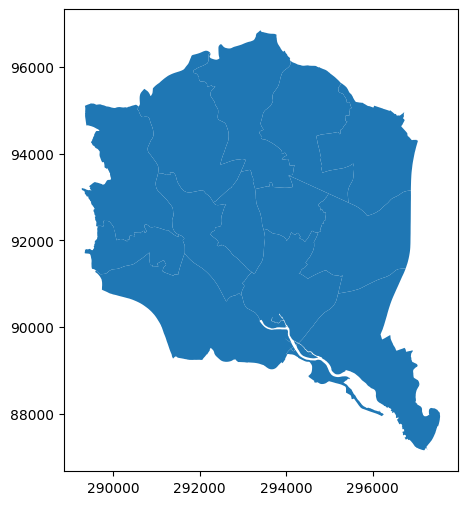

In [187]:
# basic visualisation of the districts in Barcelona using the .plot() method
ax = districts.plot(figsize=(10,6))

Exeter Wards:
['Alphington', 'Duryard and St James', 'Exwick', 'Heavitree', 'Mincinglake and Whipton', "Newtown and St Leonard's", 'Pennsylvania', 'Pinhoe', 'Priory', "St David's", 'St Loyes', 'St Thomas', 'Topsham']

Total: 13 wards


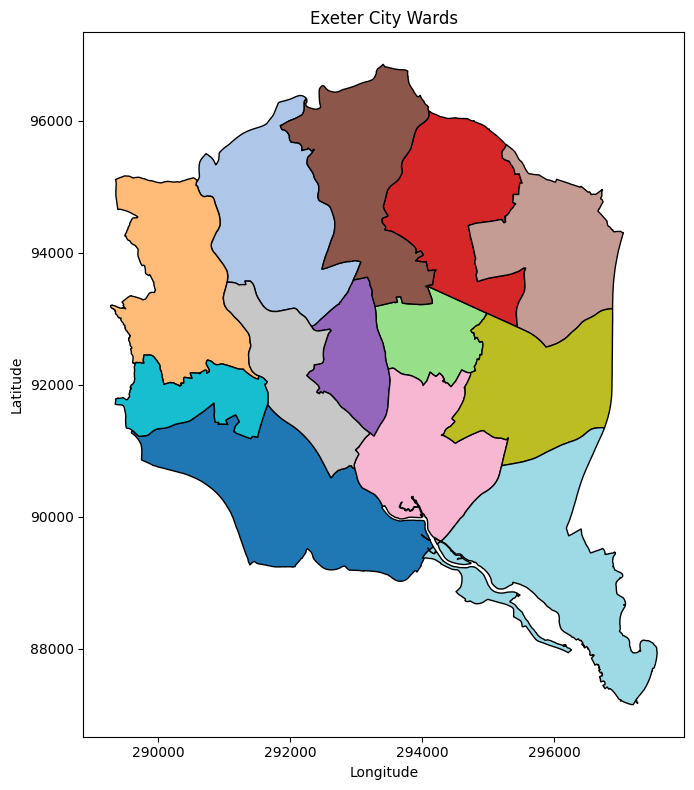

In [188]:
# use actual ward names from WD25NM column for clearer labeling
districts['ward_name'] = districts['WD25NM']
print("Exeter Wards:")
print(districts['ward_name'].tolist())
print(f"\nTotal: {len(districts)} wards")

# plot with actual ward names instead of generic index numbers
fig, ax = plt.subplots(figsize=(12, 8))
districts.plot(column='ward_name', cmap='tab20', figsize=(12, 8), edgecolor='black', legend=False, ax=ax)
ax.set_title('Exeter City Wards')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()

Ward Rankings

In [195]:
# ordering based on area size (largest to smallest)
districts_sorted = districts.sort_values(by='area_km2', ascending=False)
print("Wards ordered by area (largest to smallest):")
print(districts_sorted[['WD25NM', 'area_km2']])

Wards ordered by area (largest to smallest):
                      WD25NM  area_km2
0                 Alphington  5.663298
12                   Topsham  5.542186
1       Duryard and St James  4.546800
6               Pennsylvania  4.398304
2                     Exwick  4.167540
4    Mincinglake and Whipton  3.948516
10                  St Loyes  3.883879
7                     Pinhoe  3.789603
8                     Priory  3.455443
9                 St David's  2.483985
5   Newtown and St Leonard's  1.741540
11                 St Thomas  1.741087
3                  Heavitree  1.675028
